In [30]:
import os
import pandas as pd

In [31]:
import os
import pandas as pd

# Path to the root folder containing subdirectories
input_root_folder = "/data/weichen/ST-Library/datasets/full_pretrain_datasets"

# Initialize an empty list to store the data
data = []

# Traverse through the root folder to process CSV files
for subdir, _, files in os.walk(input_root_folder):
    for file_name in files:
        if file_name.endswith('temporal.pkl'):
            city = file_name.split('_')[0]
            type = file_name.split('_')[1]
            
            # 读取 CSV 文件
            file_path = os.path.join(subdir, file_name)
            with open(file_path, 'rb') as file:
                df = pd.read_pickle(file)
            
            # 获取文件的形状
            shape = df.shape
            temporal = shape[0]
            spatial = shape[1]
            
            # 获取时间索引的起始和结束时间
            start_time = df.index[0]
            end_time = df.index[-1]
            t_range = f"{start_time}-{end_time}"
            
            # 将信息添加到数据列表中
            data.append({
                'City': city,
                'Type': type,
                'Spatial': spatial,
                'Temporal': temporal,
                'T-Range': t_range
            })

# 创建 DataFrame
result_df = pd.DataFrame(data)

In [32]:
result_df

,City,Type,Spatial,Temporal,T-Range
0,marseille,flow,164,8641,2017-06-01 00:00:00-2017-07-01 00:00:00
1,graz,flow,272,49823,2016-04-04 00:05:00-2016-09-23 23:55:00
2,cagliari,flow,85,21600,2016-05-16 00:00:00-2016-07-29 23:55:00
3,augsburg,occ,35,5757,2017-05-06 00:00:00-2017-05-25 23:40:00
4,vilnius,flow,9,289,2015-03-17 00:00:00-2015-03-18 00:00:00
...,...,...,...,...,...
78,kassel,flow,234,1177,2016-08-28 23:55:00-2016-09-02 01:55:00
79,darmstadt,flow,163,65952,2015-09-21 00:00:00-2016-05-06 23:55:00
80,constance,occ,103,2015,2017-02-13 00:00:00-2017-02-19 23:50:00
81,manchester,occ,75,20497,2017-09-08 08:45:00-2017-11-18 12:45:00


In [33]:
# 提取不同类型的数据
df_flow = result_df[result_df['Type'] == 'flow'].sort_values(by='City')
df_speed = result_df[result_df['Type'] == 'speed'].sort_values(by='City')
df_occ = result_df[result_df['Type'] == 'occ'].sort_values(by='City')

In [34]:
df_flow

,City,Type,Spatial,Temporal,T-Range
31,augsburg,flow,40,5757,2017-05-06 00:00:00-2017-05-25 23:40:00
8,basel,flow,66,2016,2016-10-24 00:05:00-2016-10-31 00:00:00
29,bern,flow,708,2016,2016-10-24 00:05:00-2016-10-31 00:00:00
21,birmingham,flow,34,7540,2017-10-23 07:00:00-2017-11-18 11:15:00
48,bolton,flow,56,1491,2017-11-13 08:35:00-2017-11-18 12:45:00
25,bordeaux,flow,409,2016,2016-11-21 00:00:00-2016-11-27 23:55:00
16,bremen,flow,518,4032,2016-09-19 00:00:00-2016-10-02 23:55:00
2,cagliari,flow,85,21600,2016-05-16 00:00:00-2016-07-29 23:55:00
47,constance,flow,113,2015,2017-02-13 00:00:00-2017-02-19 23:50:00
79,darmstadt,flow,163,65952,2015-09-21 00:00:00-2016-05-06 23:55:00


In [15]:
df_speed

,City,Type,Spatial,Temporal,T-Range
34,birmingham,speed,4,7540,2017-10-23 07:00:00-2017-11-18 11:15:00
46,bolton,speed,16,1491,2017-11-13 08:35:00-2017-11-18 12:45:00
10,constance,speed,42,2015,2017-02-13 00:00:00-2017-02-19 23:50:00
82,essen,speed,15,54023,2017-03-27 10:00:00-2017-09-30 23:50:00
65,groningen,speed,8,4584,2017-09-21 00:00:00-2017-10-06 21:55:00
70,manchester,speed,29,20497,2017-09-08 08:45:00-2017-11-18 12:45:00
5,rotterdam,speed,70,12276,2017-09-21 00:00:00-2017-11-02 14:55:00
41,torino,speed,71,6048,2016-09-26 00:00:00-2016-10-16 23:55:00


In [16]:
df_occ

,City,Type,Spatial,Temporal,T-Range
3,augsburg,occ,35,5757,2017-05-06 00:00:00-2017-05-25 23:40:00
57,basel,occ,47,2016,2016-10-24 00:05:00-2016-10-31 00:00:00
58,bern,occ,496,2016,2016-10-24 00:05:00-2016-10-31 00:00:00
19,bolton,occ,49,1491,2017-11-13 08:35:00-2017-11-18 12:45:00
21,bordeaux,occ,198,2016,2016-11-21 00:00:00-2016-11-27 23:55:00
56,bremen,occ,365,4032,2016-09-19 00:00:00-2016-10-02 23:55:00
6,cagliari,occ,61,21600,2016-05-16 00:00:00-2016-07-29 23:55:00
80,constance,occ,103,2015,2017-02-13 00:00:00-2017-02-19 23:50:00
52,darmstadt,occ,101,65952,2015-09-21 00:00:00-2016-05-06 23:55:00
67,essen,occ,24,54023,2017-03-27 10:00:00-2017-09-30 23:50:00


In [49]:
import pickle

with open("/data/weichen/ST-Library/datasets/eval_datasets/occpairs_occupancy/occpairs_occupancy_temporal.pkl", "rb") as file:
    df_temporal = pickle.load(file)
df_temporal.shape

(96469, 106)

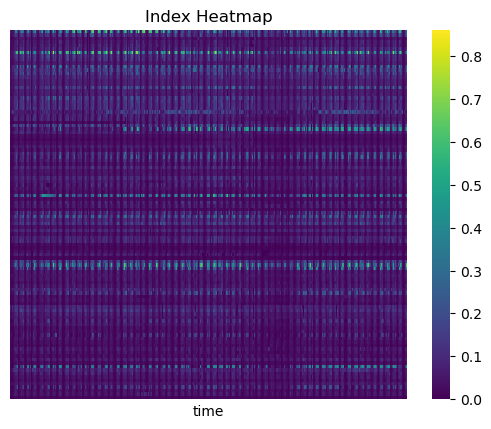

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
value_min = df_temporal.min().min()
value_max = df_temporal.max().max()

sns.heatmap(df_temporal.T.iloc[:, :], cbar=True, cmap="viridis", xticklabels=False, yticklabels=False, vmin=value_min, vmax=value_max)
plt.title("Index Heatmap")
plt.show()

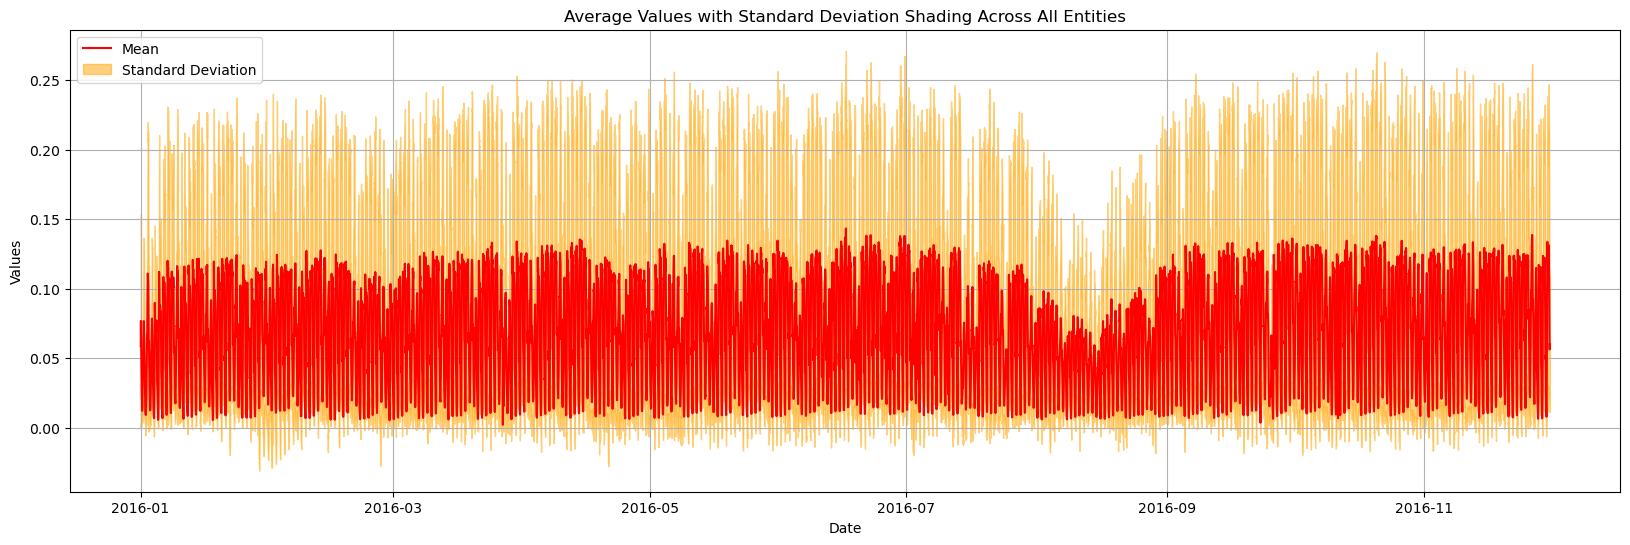

In [51]:
# 计算每个时间点的平均值和标准差

df = df_temporal[:].copy()

means = df.mean(axis=1)
std_devs = df.std(axis=1)

# Step 2: 数据可视化
plt.figure(figsize=(20, 6))

# 绘制平均值折线图
plt.plot(means.index, means, label='Mean', color='red')

# 绘制标准差范围作为阴影区域
plt.fill_between(means.index, means - std_devs, means + std_devs, color='orange', alpha=0.5, label='Standard Deviation')

plt.title('Average Values with Standard Deviation Shading Across All Entities')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()

In [45]:
import pickle

with open("/data/weichen/ST-Library/datasets/eval_datasets/occtoronto_occupancy/occtoronto_occupancy_temporal.pkl", "rb") as file:
    df_temporal = pickle.load(file)
df_temporal.shape

(44062, 62)

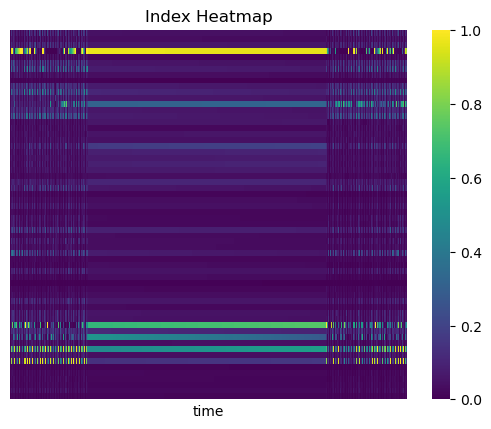

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
value_min = df_temporal.min().min()
value_max = df_temporal.max().max()

sns.heatmap(df_temporal.T.iloc[:, :], cbar=True, cmap="viridis", xticklabels=False, yticklabels=False, vmin=value_min, vmax=value_max)
plt.title("Index Heatmap")
plt.show()

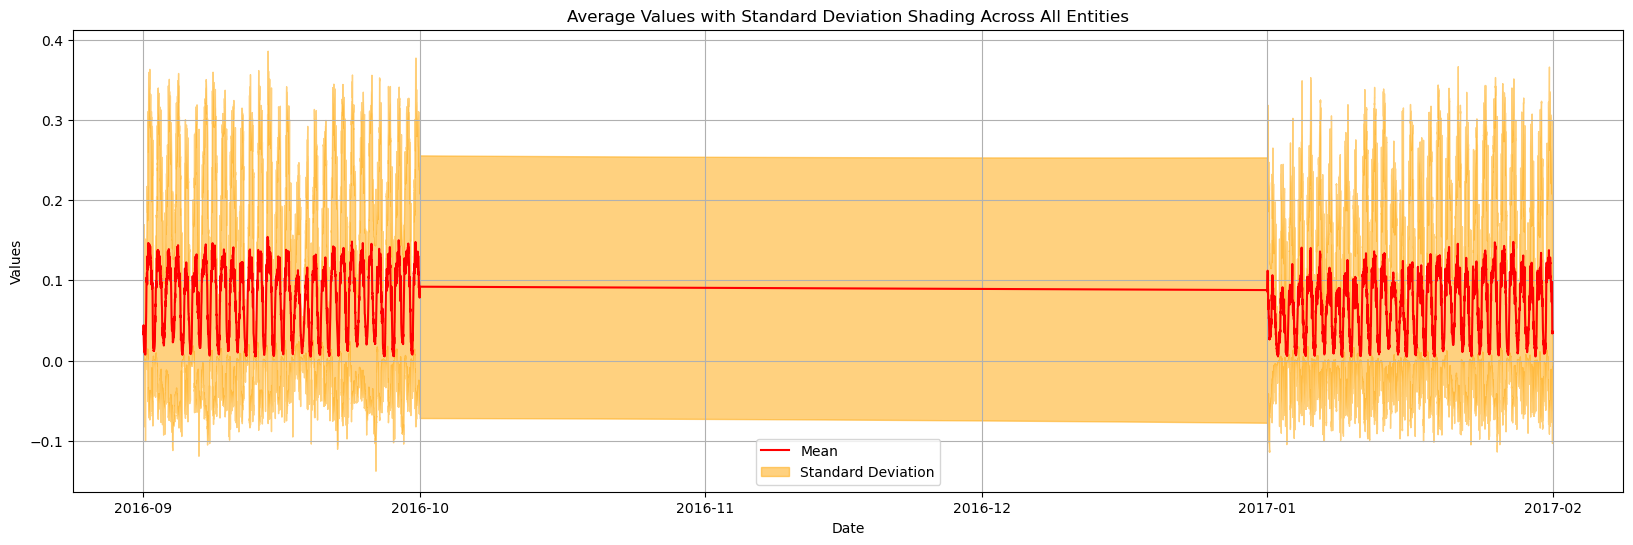

In [48]:
# 计算每个时间点的平均值和标准差

df = df_temporal[:].copy()

means = df.mean(axis=1)
std_devs = df.std(axis=1)

# Step 2: 数据可视化
plt.figure(figsize=(20, 6))

# 绘制平均值折线图
plt.plot(means.index, means, label='Mean', color='red')

# 绘制标准差范围作为阴影区域
plt.fill_between(means.index, means - std_devs, means + std_devs, color='orange', alpha=0.5, label='Standard Deviation')

plt.title('Average Values with Standard Deviation Shading Across All Entities')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()